# setup

This notebook is stand-alone to setup the postgres db and neo4j graph. Much of the code has been copied and slightly modified from earlier EDA notebooks in this folder.

In [4]:
import csv

import math
import numpy as np
import pandas as pd
import psycopg2
import neo4j
import json
from IPython.display import display

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

import ast

# Postgres Support

In [5]:
connection = psycopg2.connect(
    user = "postgres",
    password = "ucb",
    host = "postgres",
    port = "5432",
    database = "postgres"
)
cursor = connection.cursor()

In [6]:
def my_select_query_pandas(query, rollback_before_flag, rollback_after_flag):
    "function to run a select query and return rows in a pandas dataframe"
    
    if rollback_before_flag:
        connection.rollback()
    
    df = pd.read_sql_query(query, connection)
    
    if rollback_after_flag:
        connection.rollback()
    
    # fix the float columns that really should be integersb
    
    for column in df:
    
        if df[column].dtype == "float64":

            fraction_flag = False

            for value in df[column].values:
                
                if not np.isnan(value):
                    if value - math.floor(value) != 0:
                        fraction_flag = True

            if not fraction_flag:
                df[column] = df[column].astype('Int64')
    
    return(df)

In [7]:
connection.rollback()

query = """

drop table if exists cleanmovies;

"""

cursor.execute(query)

connection.commit()


In [8]:
connection.rollback()

query = """

create table cleanmovies (
    index integer,
    title varchar(4000),
    budget varchar(4000),
    genres varchar(4000),
    id integer,
    keywords varchar(4000),
    overview varchar(4000),
    popularity varchar(4000),
    vote_average varchar(4000),
    vote_count varchar(4000),
    cast_ varchar(4000),
    director varchar(4000),
    executive_producer varchar(4000),
    writer varchar(4000),
    original_music_composer varchar(4000),
    director_photography varchar(4000),
    production_country varchar(4000),
    production_company varchar(4000),
    languages varchar(4000)  
)

"""

cursor.execute(query)

connection.commit()

In [9]:
connection.rollback()

query = """

copy cleanmovies
from '/user/projects/project-3-richardshelby/data/interim/cleanmovies.csv' delimiter ',' NULL '' csv header;

"""

cursor.execute(query)

connection.commit()

## Make a subset of horror movies and calculate similarities

In [10]:
horror_df = my_select_query_pandas("""
    select 
      *
    from 
      cleanmovies
    where 
      genres ilike '%horror%'

""", rollback_before_flag=True, rollback_after_flag=True)
print(horror_df.shape)
horror_df.head()

(332, 19)


,index,title,budget,genres,id,keywords,overview,popularity,vote_average,vote_count,cast_,director,executive_producer,writer,original_music_composer,director_photography,production_country,production_company,languages
0,10,1408,25000000,Horror Thriller,3021,suicide new york hotel fire hotel room,A man who specializes in debunking paranormal ...,35.169779,6.5,1343,John Cusack Samuel L. Jackson Mary McCormack J...,Mikael H\u00e5fstr\u00f6m,"['Jake Myers', 'Bob Weinstein', 'Harvey Weinst...",None,None,['Beno\\u00eet Delhomme'],['United States of America'],"['Dimension Films', 'Di Bonaventura Pictures',...",['English']
1,28,28 Days Later,5000000,Horror Thriller Science Fiction,170,london england manchester city submachine gun ...,Twenty-eight days after a killer virus was acc...,45.490373999999996,7.1,1777,Cillian Murphy Naomie Harris Noah Huntley Chri...,Danny Boyle,None,None,['John Murphy'],['Anthony Dod Mantle'],['United Kingdom'],"['British Film Council', 'DNA Films']","['Español', 'English']"
2,29,28 Weeks Later,15000000,Horror Thriller Science Fiction,1562,london england loss of mother loss of family m...,"In this chilling sequel to 28 Days Later, the ...",34.759855,6.5,1197,Imogen Poots Robert Carlyle Rose Byrne Jeremy ...,Juan Carlos Fresnadillo,"['Alex Garland', 'Danny Boyle']",None,None,['Enrique Chediak'],"['Spain', 'United Kingdom']","['Figment Films', 'Fox Atomic', 'DNA Films', '...",['English']
3,35,30 Days of Night,30000000,Horror Thriller,4513,sunrise winter vampire marriage crisis alaska,This is the story of an isolated Alaskan town ...,33.394082,6.2,767,Josh Hartnett Melissa George Ben Foster Danny ...,David Slade,"['Aubrey Henderson', 'Mike Richardson', 'Natha...",None,['Brian Reitzell'],['Jo Willems'],"['New Zealand', 'United States of America']","['Columbia Pictures', 'HorrorFlix', 'Ghost Hou...",['English']
4,62,Abraham Lincoln: Vampire Hunter,69000000,Action Fantasy Horror,72331,usa president vampire steam locomotive america...,President Lincoln's mother is killed by a supe...,38.634767,5.5,1269,Benjamin Walker Dominic Cooper Anthony Mackie ...,Timur Bekmambetov,"['John J. Kelly', 'Michele Wolkoff', 'Simon Ki...",None,None,['Caleb Deschanel'],['United States of America'],"['Bazelevs Production', 'Abraham Productions',...",['English']


In [18]:
def words_from_list(list_of_words):
    if list_of_words == "Unknown":
        return list_of_words
    text_to_return = ""
    for count, word in enumerate(ast.literal_eval(list_of_words)):
        text_to_return += word
        if count < len(ast.literal_eval(list_of_words)) - 1:
            text_to_return += ", "
    return text_to_return


# def format_text(title, budget, genres, unused_id, keywords, overview, popularity, vote_average, vote_count, 
#                 cast, director, executive_producer, writer, original_music_composer, director_photography, 
#                 production_country, production_company, languages):
    # return f"{title} (Genres: {genres}. Keywords: {keywords}): {overview} {title} is popular among {popularity} percent of viewers. {vote_count} viewers gave this movie an average rating of {vote_average} out of 10. The cast includes {cast}. {title} was directed by {director} with {words_from_list(executive_producer)} as the executive producer(s). The movie was written by {words_from_list(writer)}. The music was originally composed by {words_from_list(original_music_composer)}, and the photography was directed by {words_from_list(director_photography)}. {title} was produced with a budget of {budget} by {words_from_list(production_company)} in {words_from_list(production_country)}."
def format_text(title, genres, keywords, overview):
    return f"{title} {genres} {keywords} {overview}"

In [21]:
#horror_movie_summaries = [format_text(*["Unknown" if data == None else data for data in row][1:]) for row in horror_df]
horror_movie_summaries = [
    format_text(row["title"], row["genres"], row["keywords"], row["overview"]) 
    for _, row in horror_df.iterrows()
]

horror_movie_summaries[:2]

['1408 Horror Thriller suicide new york hotel fire hotel room A man who specializes in debunking paranormal occurrences checks into the fabled room 1408 in the Dolphin Hotel. Soon after settling in, he confronts genuine terror.',
 "28 Days Later Horror Thriller Science Fiction london england manchester city submachine gun gas station survivor Twenty-eight days after a killer virus was accidentally unleashed from a British research facility, a small group of London survivors are caught in a desperate struggle to protect themselves from the infected. Carried by animals and humans, the virus turns those it infects into homicidal maniacs -- and it's absolutely impossible to contain."]

In [25]:
def get_embeddings(text):
    model = SentenceTransformer("all-MiniLM-L6-v2") # Source: https://sbert.net/docs/sentence_transformer/usage/usage.html
    embeddings = model.encode(text) # Result in a 1D array with 384 elements.
    embeddings_array = np.array(embeddings)
    print("Shape of embeddings:", embeddings_array.shape)
    return embeddings_array

In [31]:
horror_embeddings = np.nan_to_num(get_embeddings(horror_movie_summaries))
pd.DataFrame(horror_embeddings)

/opt/conda/lib/python3.9/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Shape of embeddings: (332, 384)


,0,1,2,3,4,5,6,7,8,9,...,374,375,376,377,378,379,380,381,382,383
0,0.016570,0.017851,-0.047454,0.040650,-0.019783,-0.000974,0.002243,-0.034596,0.056545,-0.046659,...,0.089747,-0.032532,0.034837,0.005249,-0.050499,-0.023176,0.129599,-0.007152,-0.036738,-0.011785
1,-0.001459,0.049334,0.004782,0.049471,0.034836,0.030848,0.030277,0.072543,-0.038722,0.054119,...,0.037962,0.014711,-0.024789,-0.010945,0.020035,-0.006004,-0.028237,-0.032910,-0.038425,0.010029
2,0.031784,-0.041547,0.042192,0.035778,0.094017,0.070820,-0.034690,0.020334,-0.058327,0.054657,...,0.059011,-0.041953,0.022638,0.008355,-0.013635,0.059050,-0.012251,-0.091210,0.023747,0.033658
3,-0.036821,0.063546,0.037132,0.141383,-0.031222,0.015793,-0.076106,-0.090386,0.013767,-0.064601,...,-0.046156,-0.053202,0.008272,0.013918,-0.050765,-0.035189,0.035536,-0.084411,-0.102130,0.000822
4,-0.043036,-0.028532,-0.050136,0.051347,-0.003231,0.082910,0.004480,-0.034026,-0.016217,0.021777,...,0.005640,-0.082074,0.028993,-0.030221,-0.004620,-0.033104,0.082411,-0.030173,-0.010203,-0.003605
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
327,-0.102371,-0.006453,-0.060237,0.030665,0.020570,0.004329,0.028272,0.023772,0.074887,-0.060526,...,0.118251,-0.072336,-0.024349,0.023003,-0.013847,0.057397,0.012934,0.024989,-0.052267,0.023097
328,-0.047962,-0.001819,0.017704,-0.003522,-0.014104,0.004603,0.030370,-0.054075,0.044375,-0.110410,...,0.061456,-0.022155,0.033786,0.011419,-0.091179,0.021374,0.098258,-0.001860,0.004570,-0.012406
329,-0.057140,0.058262,-0.118536,-0.011525,-0.021383,-0.022045,0.014368,0.020922,-0.004020,0.005647,...,0.024028,0.092770,0.063543,0.047182,-0.024476,0.044061,0.026851,-0.077944,0.003095,-0.001478
330,0.009290,0.054593,-0.012574,0.052898,0.021699,-0.020012,-0.001012,-0.011955,-0.034421,0.056906,...,0.092658,-0.056744,0.031181,0.074655,-0.045409,0.063242,0.070139,0.000549,-0.031716,0.026092


In [32]:
horror_similarities = cosine_similarity(horror_embeddings, horror_embeddings)
pd.DataFrame(horror_similarities)

,0,1,2,3,4,5,6,7,8,9,...,322,323,324,325,326,327,328,329,330,331
0,1.000000,0.348144,0.267173,0.359035,0.202645,0.347099,0.393036,0.333229,0.340212,0.154716,...,0.302001,0.239257,0.411824,0.289164,0.292414,0.366617,0.287554,0.266718,0.326999,0.290330
1,0.348144,1.000000,0.727788,0.284788,0.225327,0.246003,0.304377,0.349984,0.231856,0.232010,...,0.192670,0.028193,0.274569,0.327249,0.114978,0.271463,0.183581,0.405996,0.354396,0.273552
2,0.267173,0.727788,1.000000,0.276001,0.166660,0.292797,0.327274,0.368007,0.212590,0.279156,...,0.203201,0.065187,0.234771,0.308312,0.193834,0.302039,0.193841,0.400130,0.371728,0.273116
3,0.359035,0.284788,0.276001,1.000000,0.367804,0.258232,0.225339,0.256949,0.167791,0.177485,...,0.406668,0.365062,0.216109,0.403385,0.268412,0.383237,0.234481,0.258510,0.341713,0.389545
4,0.202645,0.225327,0.166660,0.367804,1.000000,0.286632,0.178419,0.106064,0.087037,0.107583,...,0.220180,0.336727,0.177710,0.234638,0.214249,0.338206,0.244681,0.196243,0.306730,0.363617
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
327,0.366617,0.271463,0.302039,0.383237,0.338206,0.441237,0.326721,0.313796,0.245545,0.242324,...,0.261668,0.365993,0.265011,0.353440,0.402657,1.000000,0.292925,0.235413,0.407768,0.387971
328,0.287554,0.183581,0.193841,0.234481,0.244681,0.416566,0.324693,0.195205,0.107065,0.159890,...,0.166466,0.165710,0.359754,0.269365,0.345370,0.292925,1.000000,0.323841,0.201352,0.231154
329,0.266718,0.405996,0.400130,0.258510,0.196243,0.302806,0.233015,0.282302,0.122874,0.247087,...,0.260469,0.133355,0.331623,0.486136,0.222845,0.235413,0.323841,1.000000,0.331130,0.460531
330,0.326999,0.354396,0.371728,0.341713,0.306730,0.442036,0.289465,0.251713,0.275207,0.268881,...,0.256885,0.289005,0.312892,0.345687,0.255243,0.407768,0.201352,0.331130,1.000000,0.420564


# Neo4J Support

In [10]:
driver = neo4j.GraphDatabase.driver(uri="neo4j://neo4j:7687", auth=("***","***"))
session = driver.session(database="neo4j")


def my_neo4j_run_query_pandas(query, **kwargs):
    "run a query and return the results in a pandas dataframe"
    result = session.run(query, **kwargs)    
    return pd.DataFrame([r.values() for r in result], columns=result.keys())


def my_neo4j_wipe_out_database():
    "wipe out database by deleting all nodes and relationships"
    
    query = "match (node)-[relationship]->() delete node, relationship"
    session.run(query)
    
    query = "match (node) delete node"
    session.run(query)
    

def my_neo4j_nodes_relationships():
    "print all the nodes and relationships"
   
    print("-------------------------")
    print("  Nodes:")
    print("-------------------------")
    
    query = """
        match (n) 
        return n.title as movie_title, labels(n) as labels
        order by n.title
    """
    
    df = my_neo4j_run_query_pandas(query)
    
    number_nodes = df.shape[0]
    
    display(df)
    
    print("-------------------------")
    print("  Relationships:")
    print("-------------------------")
    
    query = """
        match (n1)-[r]->(n2) 
        return 
            n1.title as movie_title_1, 
            labels(n1) as node_1_labels, 
            type(r) as relationship_type,
            r.weight as relationship_weight,
            n2.title as movie_title_2, 
            labels(n2) as node_2_labels
        order by 
            relationship_weight desc,
            movie_title_1, 
            movie_title_2
    """
    
    df = my_neo4j_run_query_pandas(query)
    
    number_relationships = df.shape[0]
    
    display(df)
    
    density = (2 * number_relationships) / (number_nodes * (number_nodes - 1))
    
    print("-------------------------")
    print("  Density:", f'{density:.1f}')
    print("-------------------------")
    
    return df 
    

def my_neo4j_create_relationship_two_way(from_movie_id, to_movie_id, weight):
    "create relationships two way between two movies with a weight and cost"
    
    query = """
    
    MATCH (from:Movie), 
          (to:Movie)
    WHERE from.id = $from_movie_id and to.id = $to_movie_id
    MERGE (from)-[r1:SIMILAR]->(to)
    MERGE (to)-[r2:SIMILAR]->(from)
    SET r1.weight = $weight,
        r2.weight = $weight,
        r1.cost = 1.0 - $weight,
        r2.cost = 1.0 - $weight
    """
    session.run(query, from_movie_id=from_movie_id, to_movie_id=to_movie_id, weight=weight)
    

def delimit_single_quotes(string_value):
    return string_value.replace("'", "\\'")

    
def my_neo4j_create_movie_nodes(movies, movie_count):
    """
        movies: pandas dataframe of movies
        movie_count: the number of movies to create nodes for
    """

    nquery = "CREATE \n"
    first = True

    for _, movie in movies.head(movie_count).iterrows():
        if first:
            first = False
        else:
            nquery += ",\n"
        nquery += "(:Movie {"
        nquery += f"title: '{delimit_single_quotes(movie['title'])}', "
        nquery += f"budget: {movie['budget']}, "
        nquery += f"genres: '{delimit_single_quotes(movie['genres'])}', "
        nquery += f"id: {movie['id']}, "
        # nquery += f"homepage: '{delimit_single_quotes(movie['homepage'])}', "
        # nquery += f"keywords: '{delimit_single_quotes(movie['keywords'])}', "
        # nquery += f"original_language: '{delimit_single_quotes(movie['original_language'])}', "
        # nquery += f"original_title: '{delimit_single_quotes(movie['original_title'])}', "
        nquery += f"overview: '{delimit_single_quotes(movie['overview'])}', "
        nquery += f"popularity: {movie['popularity']}, "
        nquery += f"vote_average: {movie['vote_average']}, "
        nquery += f"vote_count: {movie['vote_count']}, "
        nquery += f"movie_cast: '{delimit_single_quotes(movie['cast_'])}', "
        nquery += f"director: '{delimit_single_quotes(movie['director'])}', "
        # nquery += f"executive_producer: '{delimit_single_quotes(words_from_list(movie['executive_producer']))}', "
        # nquery += f"writer: '{delimit_single_quotes(words_from_list(movie['writer']))}', "
        # nquery += f"original_music_composer: '{delimit_single_quotes(words_from_list(movie['original_music_composer']))}', "
        # nquery += f"director_photography: '{delimit_single_quotes(words_from_list(movie['director_photography']))}', "
        nquery += f"production_country: '{delimit_single_quotes(words_from_list(movie['production_country']))}', "
        nquery += f"production_company: '{delimit_single_quotes(words_from_list(movie['production_company']))}'"
        # nquery += f"production_countries: {movie['production_countries']}, "
        # nquery += f"release_date: date('{movie['release_date']}'), "
        # nquery += f"revenue: {movie['revenue']}, "
        # nquery += f"runtime: {movie['runtime']}, "
        # nquery += f"spoken_languages: {movie['spoken_languages']}, "
        # nquery += f"status: '{delimit_single_quotes(movie['status'])}', "
        # nquery += f"tagline: '{delimit_single_quotes(movie['tagline'])}', "
        # same problem, no delimiter between people. 
        #    space used to seperate first name, last name, and people
        # nquery += f"movie_cast: '{delimit_single_quotes(movie['cast'])}', "

        # this does not feel applicable
        # nquery += f"crew: '{delimit_single_quotes(movie['crew'])}', "

        # nquery += f"director: '{delimit_single_quotes(movie['director'])}'"
        nquery += "})"
    nquery += ";"
    session.run(nquery)
    

def my_neo4j_create_top_3_similarity_links(movies, movie_count, cosine_similarity_matrix):
    """
        movies: pandas dataframe of movies
        movie_count: the number of movies to create nodes for        
        cosine_similarity_matrix: similarity matrix in the range [-1, 1] where 
            -1 is opposite taste
             0 is no similarity
             1 is perfect match
             
        note - this is hardcoded to top 3 but we can make it general if needed
    """

    for movie_idx in range(movie_count):
        # track top 3 movie by index and score
        similar_1_idx = -1
        similar_2_idx = -1
        similar_3_idx = -1
        similar_1_score = -1
        similar_2_score = -1
        similar_3_score = -1

        for movie_idx_compare in range(movie_count):
            
            # only compare movies to other movies
            if movie_idx == movie_idx_compare:
                continue
                
            similarity_score = cosine_similarity_matrix[movie_idx][movie_idx_compare]

            if similarity_score > similar_1_score:
                similar_3_idx = similar_2_idx
                similar_3_score = similar_2_score

                similar_2_idx = similar_1_idx            
                similar_2_score = similar_1_score

                similar_1_idx = movie_idx_compare            
                similar_1_score = similarity_score

            elif similarity_score > similar_2_score:
                similar_3_idx = similar_2_idx
                similar_3_score = similar_2_score

                similar_2_idx = movie_idx_compare
                similar_2_score = similarity_score

            elif similarity_score > similar_3_score:
                similar_3_idx = movie_idx_compare
                similar_3_score = similarity_score

        most_similar_array = [
            (similar_1_idx, similar_1_score),
            (similar_2_idx, similar_2_score),
            (similar_3_idx, similar_3_score)
        ]
        
        for similar_idx, similar_score in most_similar_array:
            my_neo4j_create_relationship_two_way(
                from_movie_id = movies.iloc[movie_idx].id, 
                to_movie_id = movies.iloc[similar_idx].id, 
                weight = round(similar_score, 5)
            )

In [46]:
# start fresh
my_neo4j_wipe_out_database()

my_neo4j_create_movie_nodes(horror_df, len(horror_df))
my_neo4j_create_top_3_similarity_links(horror_df, len(horror_df), horror_similarities)

my_neo4j_nodes_relationships()

-------------------------
  Nodes:
-------------------------


,movie_title,labels
0,1408,[Movie]
1,28 Days Later,[Movie]
2,28 Weeks Later,[Movie]
3,30 Days of Night,[Movie]
4,A Haunted House,[Movie]
...,...,...
327,Wrong Turn,[Movie]
328,Zombieland,[Movie]
329,[REC],[Movie]
330,[REC]²,[Movie]


-------------------------
  Relationships:
-------------------------


,movie_title_1,node_1_labels,relationship_type,relationship_weight,movie_title_2,node_2_labels
0,Friday the 13th Part VI: Jason Lives,[Movie],SIMILAR,0.89635,Friday the 13th: A New Beginning,[Movie]
1,Friday the 13th: A New Beginning,[Movie],SIMILAR,0.89635,Friday the 13th Part VI: Jason Lives,[Movie]
2,A Nightmare on Elm Street 3: Dream Warriors,[Movie],SIMILAR,0.86393,A Nightmare on Elm Street 4: The Dream Master,[Movie]
3,A Nightmare on Elm Street 4: The Dream Master,[Movie],SIMILAR,0.86393,A Nightmare on Elm Street 3: Dream Warriors,[Movie]
4,A Nightmare on Elm Street,[Movie],SIMILAR,0.85303,A Nightmare on Elm Street 3: Dream Warriors,[Movie]
...,...,...,...,...,...,...
1539,Pandorum,[Movie],SIMILAR,0.31876,Apollo 18,[Movie]
1540,I Spit on Your Grave,[Movie],SIMILAR,0.31810,Scream,[Movie]
1541,Scream,[Movie],SIMILAR,0.31810,I Spit on Your Grave,[Movie]
1542,Firestarter,[Movie],SIMILAR,0.30762,New Nightmare,[Movie]


-------------------------
  Density: 0.0
-------------------------


,movie_title_1,node_1_labels,relationship_type,relationship_weight,movie_title_2,node_2_labels
0,Friday the 13th Part VI: Jason Lives,[Movie],SIMILAR,0.89635,Friday the 13th: A New Beginning,[Movie]
1,Friday the 13th: A New Beginning,[Movie],SIMILAR,0.89635,Friday the 13th Part VI: Jason Lives,[Movie]
2,A Nightmare on Elm Street 3: Dream Warriors,[Movie],SIMILAR,0.86393,A Nightmare on Elm Street 4: The Dream Master,[Movie]
3,A Nightmare on Elm Street 4: The Dream Master,[Movie],SIMILAR,0.86393,A Nightmare on Elm Street 3: Dream Warriors,[Movie]
4,A Nightmare on Elm Street,[Movie],SIMILAR,0.85303,A Nightmare on Elm Street 3: Dream Warriors,[Movie]
...,...,...,...,...,...,...
1539,Pandorum,[Movie],SIMILAR,0.31876,Apollo 18,[Movie]
1540,I Spit on Your Grave,[Movie],SIMILAR,0.31810,Scream,[Movie]
1541,Scream,[Movie],SIMILAR,0.31810,I Spit on Your Grave,[Movie]
1542,Firestarter,[Movie],SIMILAR,0.30762,New Nightmare,[Movie]


# Shortest Path (Dijkstra)

Shortest Path (Dijkstra): From a seed movie, trace to similar unwatched ones via weighted paths—shorter/higher-weight paths yield "next watch" chains.

- Pick two seed movies and find the shortest (most similar) path between the twp
- Dijkstra requires a shortest value, compute a cost = 1 - similarity (perfect similarity = 0 cost, less similarity will increase the cost)
- Pick two movies within the same genre to test


## Setup the Neo4J in-memory graph

In [47]:
query = "CALL gds.graph.drop('ds_graph', false) yield graphName"
session.run(query)

query = "CALL gds.graph.project('ds_graph', 'Movie', 'SIMILAR', {relationshipProperties: 'cost'})"
session.run(query)

## Given two watched movies, find other related movies

- within the Horror genre, find similar sub-genres to pick some "watched" movies and find a connection
- limitation: direct connection
  - if there is a direct connection we do intermediate recommendations
  - future fix could be to exclude the direct connection between watched movies

## find some horror / comedy movies to use

In [52]:
horror_comedy_df = horror_df[horror_df["genres"].str.contains("comedy", case=False)]
print(horror_comedy_df.shape)
horror_comedy_df.head()

(39, 19)


,index,title,budget,genres,id,keywords,overview,popularity,vote_average,vote_count,cast_,director,executive_producer,writer,original_music_composer,director_photography,production_country,production_company,languages
6,94,A Haunted House,2500000,Comedy Horror,139038,horror spoof found footage duringcreditsstinger,"A spoof of all the ""found-footage/documentary ...",18.661541,5.4,516,Marlon Wayans Essence Atkins Nick Swardson Ced...,Michael Tiddes,None,"['Rick Alvarez', 'Marlon Wayans']",None,['Steve Gainer'],['United States of America'],"['Open Road Films', 'Endgame Entertainment', '...",['English']
22,217,Arachnophobia,31000000,Comedy Horror,6488,small town outbreak exterminator spider bite c...,A large spider from the jungles of South Ameri...,15.895660999999999,6.2,433,Jeff Daniels Harley Jane Kozak Garette Ratliff...,Frank Marshall,"['Frank Marshall', 'Steven Spielberg']",None,['Trevor Jones'],['Mikael Salomon'],['United States of America'],"['Tangled Web Productions', 'Amblin Entertainm...","['Español', 'English']"
31,416,Bride of Chucky,25000000,Horror Comedy,11932,route 66 puppet evil doll killer doll killer toys,"Chucky hooks up with another murderous doll, t...",14.340095000000002,5.5,350,Ed Gale Jennifer Tilly Brad Dourif Katherine H...,Ronny Yu,"['Don Mancini', 'Corey Sienega']",None,None,['Peter Pau'],"['United States of America', 'Canada']","['Midwinter Productions Inc.', 'Universal Pict...",['English']
37,540,Club Dread,8500000,Comedy Horror,11217,island machete beautiful woman serial killer m...,When a serial killer interrupts the fun at the...,2.62082,5.1,107,Kevin Heffernan Jay Chandrasekhar Paul Soter E...,Jay Chandrasekhar,"['Peter E. Lengyel', 'Lance Hool']",None,['Nathan Barr'],['Lawrence Sher'],['United States of America'],"['Coconut Pete Productions', 'Fox Searchlight ...",['English']
38,584,Creepshow,8000000,Horror Comedy Fantasy,16281,monster halloween meteor buried alive cockroach,"Inspired by the E.C. comics of the 1950s, Geor...",13.661289000000002,6.7,226,Hal Holbrook Adrienne Barbeau Fritz Weaver Les...,George A. Romero,['Salah M. Hassanein'],None,['John Harrison'],['Michael Gornick'],['United States of America'],"['Laurel Entertainment Inc.', 'Creepshow Films...","['English', 'Italiano']"


## horror / comedy graph

`match(n:Movie) where toLower(n.genres) contains "comedy" return n;`



In [73]:
query = """

MATCH (source:Movie {title: $source}), (target:Movie {title: $target})
CALL gds.shortestPath.dijkstra.stream(
    'ds_graph', 
    { sourceNode: source, 
      targetNode: target, 
      relationshipWeightProperty: 'cost'
    }
)
YIELD index, sourceNode, targetNode, totalCost, nodeIds, costs, path
RETURN
    gds.util.asNode(sourceNode).title AS from,
    gds.util.asNode(targetNode).title AS to,
    totalCost,
    [nodeId IN nodeIds | gds.util.asNode(nodeId).title] AS nodes,
    costs
ORDER BY index

"""

source, target = horror_comedy_df.sample(n=2)["title"].tolist()
recommendations = my_neo4j_run_query_pandas(query, source=source, target=target)
print("watched movies:")
print("-- ", source)
print("-- ", target)
print("recommended movies:")
for node_path in recommendations["nodes"]:
    for movie_title in node_path[1:-1]:
        print("-- ", movie_title)

watched movies:
--  Dylan Dog: Dead of Night
--  Lake Placid
recommended movies:
--  Cursed
--  Don't Be Afraid of the Dark
--  C.H.U.D.
--  Split Second


## create some additional relationships for slide 

In [11]:
query = """
MATCH (from:Movie), 
      (to:Movie)
WHERE from.title = $from_movie_title and to.title = $to_movie_title
MERGE (from)-[r1:RECOMMENDED]->(to)
"""

session.run(query, from_movie_title="Dylan Dog: Dead of Night", to_movie_title="Cursed")
session.run(query, from_movie_title="Cursed", to_movie_title="Don't Be Afraid of the Dark")
session.run(query, from_movie_title="Don't Be Afraid of the Dark", to_movie_title="C.H.U.D.")
session.run(query, from_movie_title="C.H.U.D.", to_movie_title="Split Second")
session.run(query, from_movie_title="Split Second", to_movie_title="Lake Placid")

## query these movies in the UI

* show the whole graph
* match the watched nodes
* connect the watched nodes via recommendations
* include background nodes to give a better visual
* use labels so we can color the nodes in Neo4J UI

```
match p = ()--()

with p

match (a:Movie {title: "Dylan Dog: Dead of Night"})
match (b:Movie {title: "Cursed"})
match (c:Movie {title: "Don't Be Afraid of the Dark"})
match (d:Movie {title: "C.H.U.D."})
match (e:Movie {title: "Split Second"})
match (f:Movie {title: "Lake Placid"})


set a:watched
set f:watched

set b:recommended
set c:recommended
set d:recommended
set e:recommended

with p, a, b, c, d, e, f

match
  (a)-[r1:RECOMMENDED]->(b),
  (b)-[r2:RECOMMENDED]->(c),
  (c)-[r3:RECOMMENDED]->(d),
  (d)-[r4:RECOMMENDED]->(e),
  (e)-[r5:RECOMMENDED]->(f)

set r1.highlight = true,
    r2.highlight = true,
    r3.highlight = true,
    r4.highlight = true,
    r5.highlight = true

return p
```

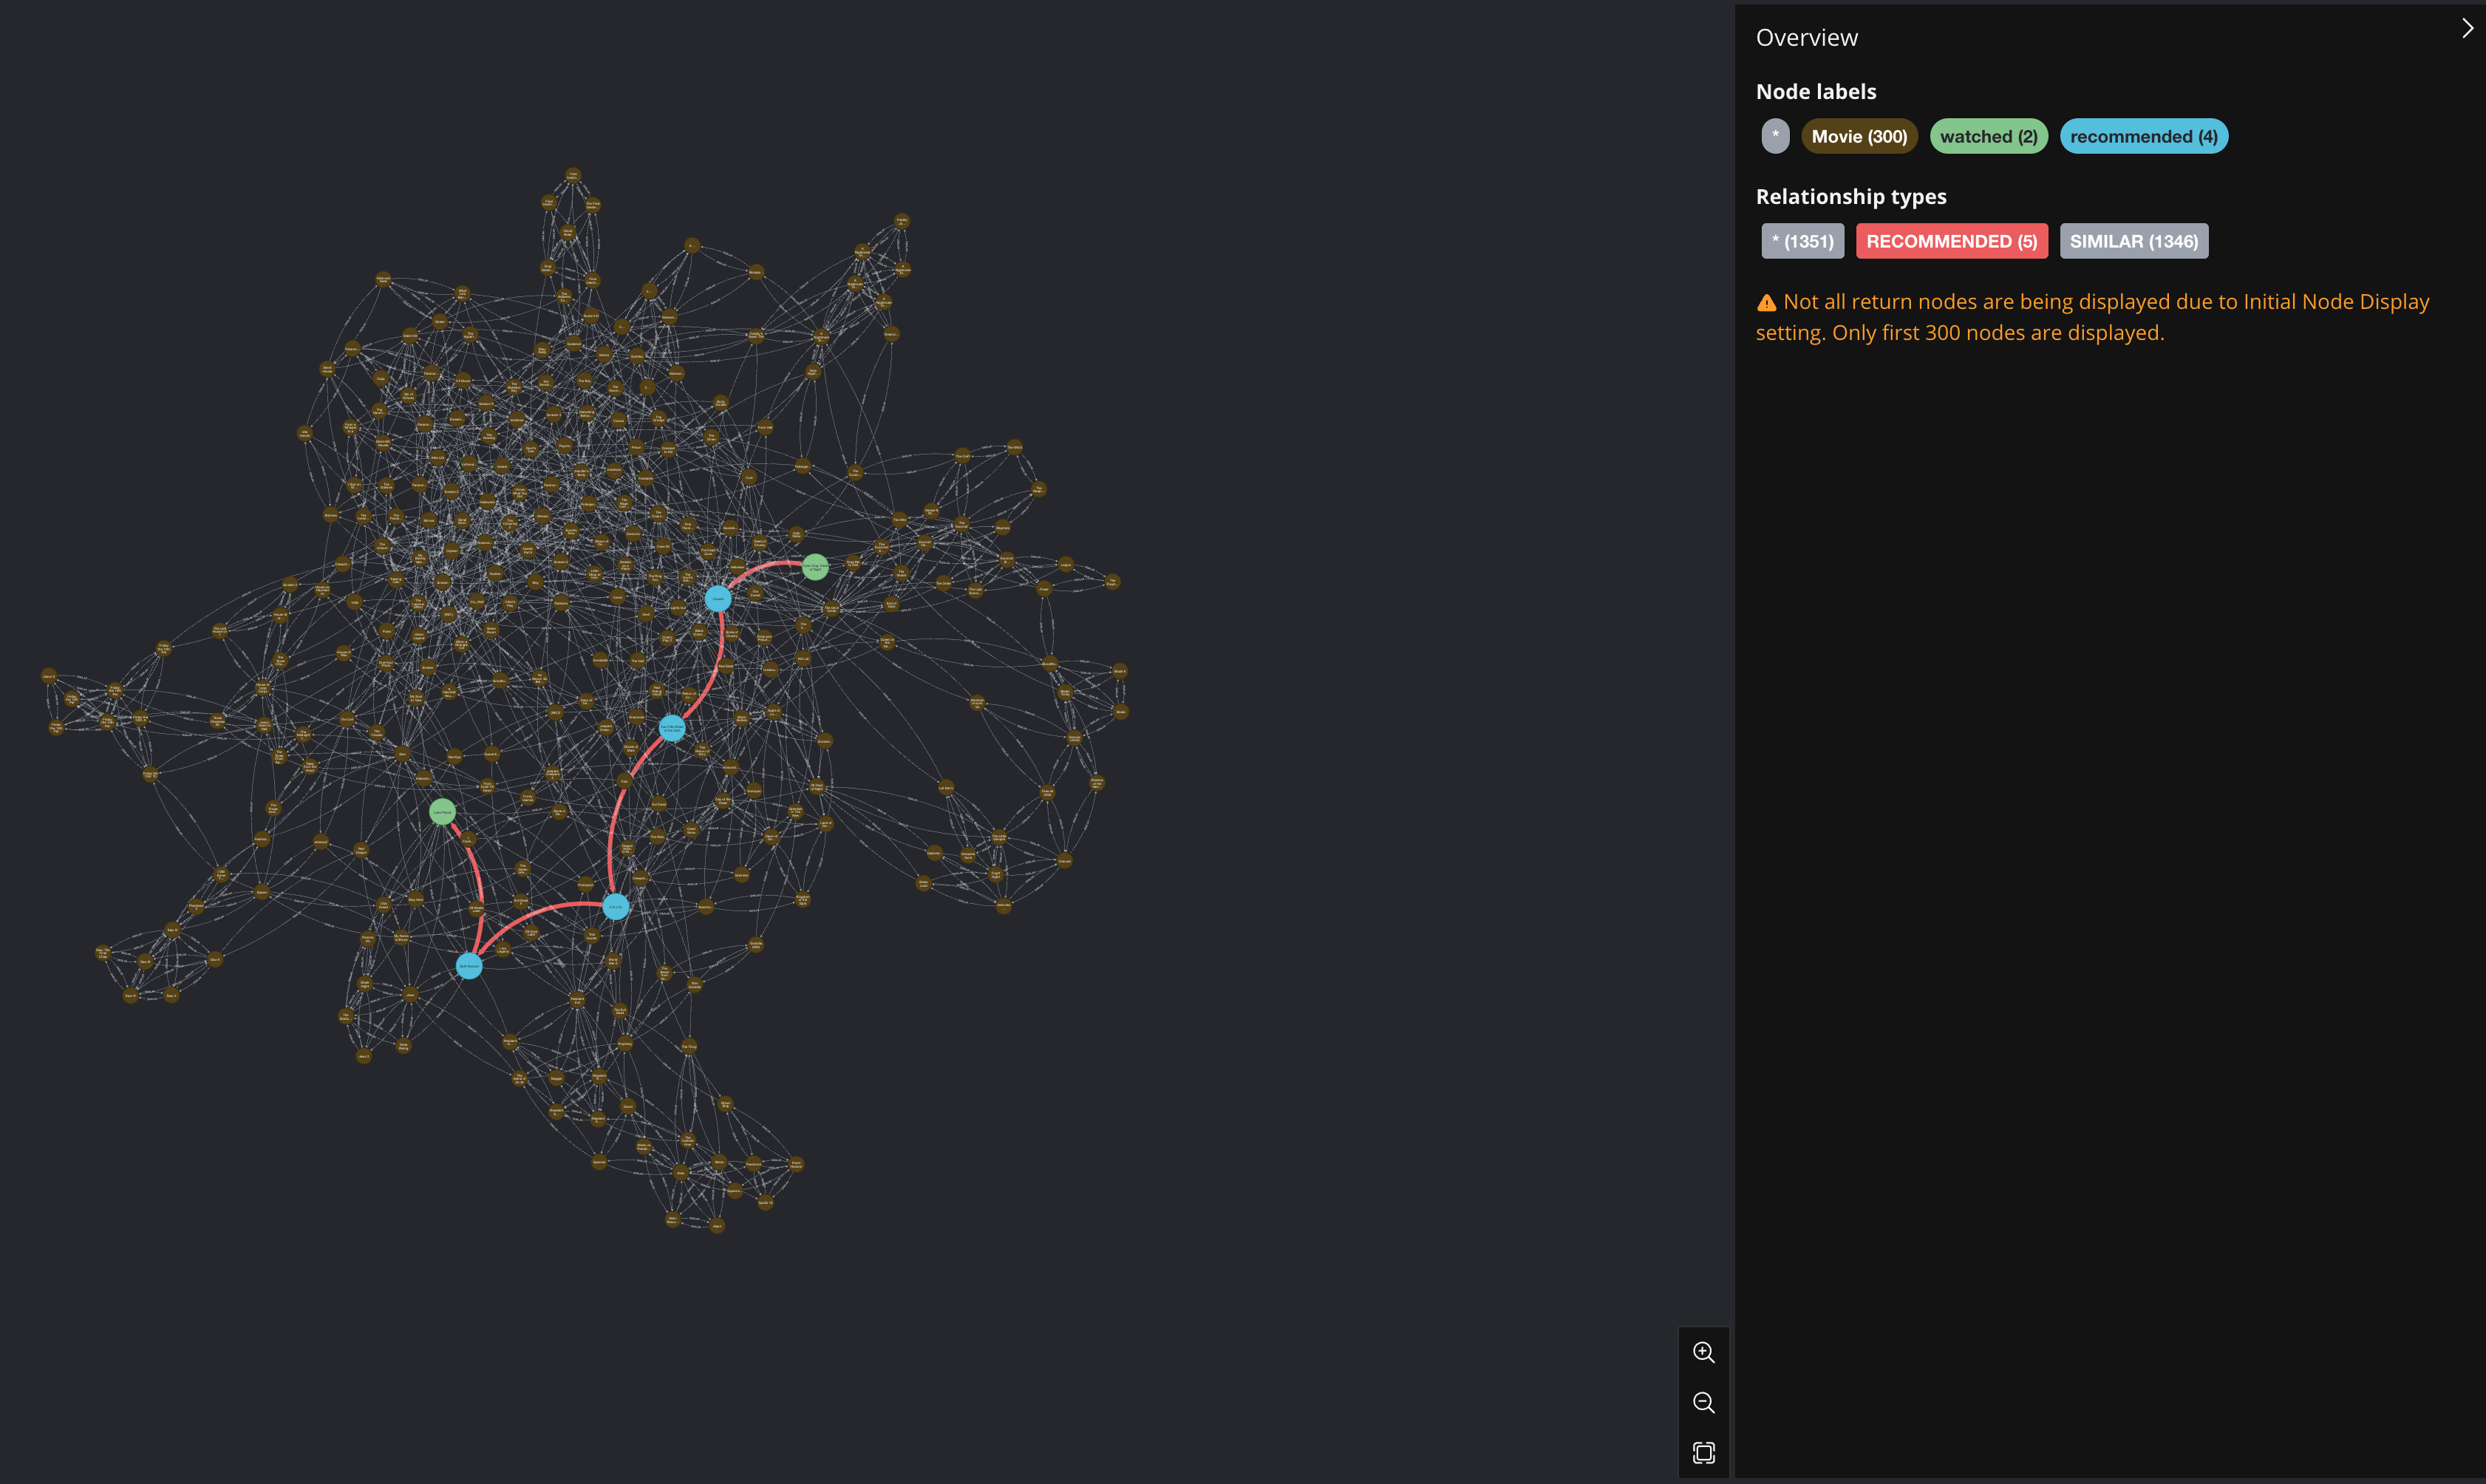